0. Imports and Setup

In [10]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset
from PIL import Image

1. Set paths

In [11]:
DATA_DIR = os.path.abspath("dataset")

ANNOTATIONS = {
    "lpl_train": os.path.join(DATA_DIR, "lpl/train/lpl_train.json"),
    "lpl_test": os.path.join(DATA_DIR, "lpl/test/lpl_test.json"),
    "stucco_train": os.path.join(DATA_DIR, "stucco/train/stucco_train.json"),
    "stucco_test": os.path.join(DATA_DIR, "stucco/test/stucco_test.json"),
}

2. Load JSON

In [12]:
def load_via_json(path):
    with open(path) as f:
        data = json.load(f)
    return data

3. Convert JSON to a sample list, where each sample keeps the image path, annotations, task and split.

In [13]:
def build_samples():
    samples = []

    for key, path in ANNOTATIONS.items():
        task, split = key.split("_")  # lpl_train → (lpl, train)
        data = load_via_json(path)

        for _, entry in data.items():
            filename = entry["filename"]
            regions = list(entry["regions"].values())

            samples.append({
                "filename": filename,
                "img_path": os.path.join(DATA_DIR, task, split, filename),
                "regions": regions,
                "task": task,
                "split": split
            })

    return samples

samples = build_samples()
print("Total samples:", len(samples))

Total samples: 20


4. Transform polygon points into binary masks for instance segmentation

In [14]:
def polygon_to_mask(height, width, all_x, all_y):
    mask = np.zeros((height, width), dtype=np.uint8)
    pts = np.array(list(zip(all_x, all_y)), dtype=np.int32)

    if len(pts) < 3:
        return None

    cv2.fillPoly(mask, [pts], 1)
    return mask

5. Build the `target` dictionary expected by torchvision detection models (Mask R-CNN).

In [15]:
class ArtDataset(Dataset):
    def __init__(self, samples, transforms=None):
        self.samples = samples
        self.transforms = transforms

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img_path = sample["img_path"]

        img = Image.open(img_path).convert("RGB")
        img_np = np.array(img)
        h, w = img_np.shape[:2]

        masks = []
        boxes = []

        for region in sample["regions"]:
            shape = region.get("shape_attributes", {})

            if shape.get("name") != "polygon":
                continue

            all_x = shape.get("all_points_x", [])
            all_y = shape.get("all_points_y", [])

            if len(all_x) < 3 or len(all_x) != len(all_y):
                continue

            mask = polygon_to_mask(h, w, all_x, all_y)
            if mask is None or mask.sum() == 0:
                continue

            y_indices, x_indices = np.where(mask == 1)
            if len(x_indices) == 0 or len(y_indices) == 0:
                continue

            xmin = np.min(x_indices)
            xmax = np.max(x_indices)
            ymin = np.min(y_indices)
            ymax = np.max(y_indices)

            if xmax <= xmin or ymax <= ymin:
                continue

            masks.append(mask)
            boxes.append([xmin, ymin, xmax, ymax])

        if len(masks) == 0:
            # caso edge: imagen sin regiones válidas
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            masks = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)

        labels = torch.ones((len(boxes),), dtype=torch.int64)  # 1 clase
        image_id = torch.tensor([idx])

        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) \
            if len(boxes) > 0 else torch.tensor([])

        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        img = torch.as_tensor(img_np / 255.0, dtype=torch.float32).permute(2, 0, 1)

        return img, target

6. Split train/test

In [16]:
train_samples = [s for s in samples if s["split"] == "train"]
test_samples = [s for s in samples if s["split"] == "test"]

train_dataset = ArtDataset(train_samples)
test_dataset = ArtDataset(test_samples)

print(len(train_dataset), len(test_dataset))

14 6


7. Visual verification of boxes and masks before training.

In [ ]:
def show_sample(dataset, idx):
    img, target = dataset[idx]

    img_np = img.permute(1, 2, 0).numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(img_np)

    for box in target["boxes"]:
        xmin, ymin, xmax, ymax = box
        plt.gca().add_patch(
            plt.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                color='red',
                linewidth=1
            )
        )

    plt.title(f"Instances: {len(target['boxes'])}")
    plt.axis("off")
    plt.show()

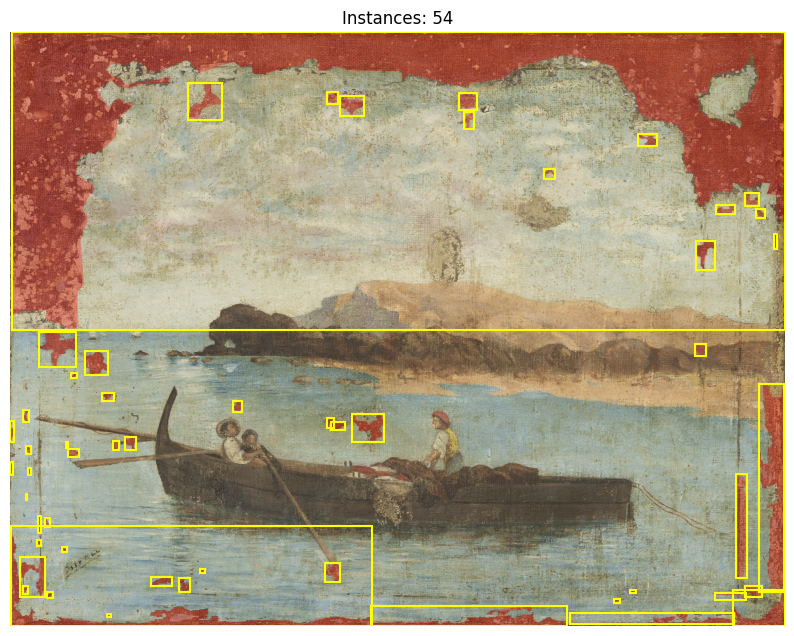

KeyboardInterrupt: 

In [18]:
show_sample(train_dataset, 0)
show_sample(train_dataset, 3)
show_sample(test_dataset, 0)